
# Frequency Spectrum Comparative Analysis: Global vs Patched Wiener Loss

This notebook performs a detailed **frequency spectrum analysis** comparing the performance of:
1. **Global Wiener Loss (GWL)**
2. **Patched Wiener Loss (PWL)**

We analyse:
- Spectral error maps.
- Radial frequency error profiles.
- Per-band fidelity metrics.
- Visual comparisons of spectra.


In [1]:
import os 

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift


In [2]:
def find_checkpoint(root_dir, loss_name, epoch=None):
    """
    Find checkpoint for specified epoch or latest if not specified
    
    Args:
        root_dir (str): Path to root directory containing checkpoints
        epoch (int, optional): Specific epoch to load, if None loads latest
        
    Returns:
        str: Path to checkpoint file
        int: Epoch number found
    """
    # Get all files in directory
    files = os.listdir(root_dir)
    
    # Filter for checkpoint files and extract epoch numbers
    epoch_nums = []
    for f in files:
        if (f.endswith('.pth') or f.endswith('.pt')) and f.split("_")[0] == loss_name:
            try:
                # Extract epoch number from filename
                file_epoch = int(''.join(filter(str.isdigit, f)))
                epoch_nums.append((file_epoch, f))
            except ValueError:
                continue
    
    if not epoch_nums:
        raise FileNotFoundError(f"No checkpoint files found in {root_dir} for loss {loss_name}")
        
    if epoch is not None:
        # Try to find specified epoch
        matching = [x for x in epoch_nums if x[0] == epoch]
        if matching:
            return os.path.join(root_dir, matching[0][1]), matching[0][0]
        print(f"Warning: Epoch {epoch} not found, using latest instead")
        
    # Get file with highest epoch
    latest_epoch, latest_file = max(epoch_nums, key=lambda x: x[0])
    return os.path.join(root_dir, latest_file), latest_epoch

def load_checkpoint(root_dir, loss_name, epoch=None):
    """
    Load checkpoint for specified epoch or latest if not specified
    
    Args:
        root_dir (str): Path to checkpoints directory
        model: PyTorch model to load weights into
        epoch (int, optional): Specific epoch to load, if None loads latest
        
    Returns:
        model: Model with loaded weights
        int: Epoch number of loaded checkpoint
    """
    checkpoint_path, loaded_epoch = find_checkpoint(root_dir, loss_name, epoch)
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    print(f"Loaded {loss_name} checkpoint from epoch {loaded_epoch}: {checkpoint_path}")
    return checkpoint

def load_images(root_dir, loss_name, epoch=None):
    ckpt = load_checkpoint(root_dir, loss_name, epoch)

    # get data from checkpoint
    original = ckpt["data"]
    recon = ckpt["output"].detach()
    return original, recon

def load_images_all_epochs(root_dir, loss_name):
    _, epoch = find_checkpoint(root_dir, loss_name)

    original, recon = [], []
    for i in range(1, epoch + 1):
        ckpt = load_checkpoint(root_dir, loss_name, i)

        original.append(ckpt["data"])
        recon.append(ckpt["output"].detach())

    original = torch.from_numpy(np.array(original))
    recon = torch.from_numpy(np.array(recon))

    return original, recon

In [3]:

def compute_fft_magnitude(image):
    image_np = image.cpu().squeeze().numpy()
    spectrum = np.abs(fftshift(fft2(image_np)))
    log_spectrum = np.log1p(spectrum)
    return log_spectrum


In [4]:

def radial_profile(data):
    y, x = np.indices((data.shape))
    center = np.array([x.max()/2.0, y.max()/2.0])
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / np.maximum(nr, 1)
    return radialprofile


In [5]:
def radial_snr(orig_fft, recon_fft):
    # Compute squared error and signal power
    error = (orig_fft - recon_fft) ** 2
    signal = orig_fft ** 2
    
    # Radial coordinates
    y, x = np.indices(orig_fft.shape)
    center = np.array([x.shape[1] // 2, y.shape[0] // 2])
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2).astype(int)
    
    # Radial binning
    signal_bin = np.bincount(r.ravel(), signal.ravel())
    error_bin = np.bincount(r.ravel(), error.ravel())
    nr = np.bincount(r.ravel())
    
    # Compute average SNR
    signal_profile = signal_bin / np.maximum(nr, 1)
    error_profile = error_bin / np.maximum(nr, 1)
    snr_profile = 10 * np.log10(signal_profile / np.maximum(error_profile, 1e-10))
    
    radii = np.arange(len(snr_profile))
    return radii, snr_profile


In [6]:

def visualize_spectra_comparison(original, recon_gwl, recon_pwl, recon_mse, num_images=5):
    fig, axes = plt.subplots(8, num_images, figsize=(15, 16))
    for i in range(num_images):
        # Plot original image and its spectrum
        axes[0, i].imshow(original[i].cpu().squeeze().permute(1, 2, 0), cmap='gray')
        axes[0, i].set_title("Original Image")
        axes[0, i].axis('off')

        orig_fft = compute_fft_magnitude(original[i])
        axes[1, i].imshow(orig_fft[0], cmap='gray')
        axes[1, i].set_title("Original Spectrum")
        axes[1, i].axis('off')

        # Plot GWL reconstruction and its spectrum
        axes[2, i].imshow(recon_gwl[i].cpu().squeeze().permute(1, 2, 0), cmap='gray')
        axes[2, i].set_title("GWL Reconstruction")
        axes[2, i].axis('off')

        gwl_fft = compute_fft_magnitude(recon_gwl[i])
        axes[3, i].imshow(gwl_fft[0], cmap='gray')
        axes[3, i].set_title("GWL Spectrum")
        axes[3, i].axis('off')

        # Plot PWL reconstruction and its spectrum
        axes[4, i].imshow(recon_pwl[i].cpu().squeeze().permute(1, 2, 0), cmap='gray')
        axes[4, i].set_title("PWL Reconstruction")
        axes[4, i].axis('off')

        pwl_fft = compute_fft_magnitude(recon_pwl[i])
        axes[5, i].imshow(pwl_fft[0], cmap='gray')
        axes[5, i].set_title("PWL Spectrum")
        axes[5, i].axis('off')

        # Plot MSE reconstruction and its spectrum
        axes[6, i].imshow(recon_mse[i].cpu().squeeze().permute(1, 2, 0), cmap='gray')
        axes[6, i].set_title("MSE Reconstruction")
        axes[6, i].axis('off')

        mse_fft = compute_fft_magnitude(recon_mse[i])
        axes[7, i].imshow(mse_fft[0], cmap='gray')
        axes[7, i].set_title("MSE Spectrum")
        axes[7, i].axis('off')

    plt.tight_layout()
    plt.show()


In [7]:

def plot_radial_profiles(original, recon_gwl, recon_pwl, recon_mse, num_images=5):
    plt.figure(figsize=(10,5))
    
    # get the first num_images colours
    colors = plt.cm.tab10.colors[:num_images]
    for i in range(num_images):
        orig_fft = compute_fft_magnitude(original[i])[0]
        gwl_fft = compute_fft_magnitude(recon_gwl[i])[0]
        pwl_fft = compute_fft_magnitude(recon_pwl[i])[0]
        mse_fft = compute_fft_magnitude(recon_mse[i])[0]

        orig_profile = radial_profile(orig_fft)
        gwl_profile = radial_profile(gwl_fft)
        pwl_profile = radial_profile(pwl_fft)
        mse_profile = radial_profile(mse_fft)

        plt.plot(orig_profile, label=f'Orig {i+1}', linestyle='-', color=colors[i])
        # plt.plot(gwl_profile, label=f'GWL {i+1}', linestyle='--', marker='s', color=colors[i])
        plt.plot(pwl_profile, label=f'PWL {i+1}', linestyle='--', marker='^', color=colors[i])
        plt.plot(mse_profile, label=f'MSE {i+1}', linestyle='--', marker='*', color=colors[i])

    plt.xlabel('Frequency Radius')
    plt.ylabel('Magnitude (log)')
    plt.title('Radial Frequency Profiles')
    plt.legend(loc='lower left')
    plt.show()

def plot_radial_snr(original, recon_gwl, recon_pwl, recon_mse, num_images=5):
    plt.figure(figsize=(10,5))
    
    # get the first num_images colours
    colors = plt.cm.tab10.colors[:num_images]
    for i in range(num_images):
        orig_fft = compute_fft_magnitude(original[i])[0]
        gwl_fft = compute_fft_magnitude(recon_gwl[i])[0]
        pwl_fft = compute_fft_magnitude(recon_pwl[i])[0]
        mse_fft = compute_fft_magnitude(recon_mse[i])[0]

        gwl_radii, gwl_snr = radial_snr(orig_fft, gwl_fft)
        pwl_radii, pwl_snr = radial_snr(orig_fft, pwl_fft)
        mse_radii, mse_snr = radial_snr(orig_fft, mse_fft)

        # plt.plot(gwl_radii, gwl_snr, label=f'GWL {i+1}', linestyle='--', marker='s', color=colors[i])
        plt.plot(pwl_radii, pwl_snr, label=f'PWL {i+1}', linestyle='--', marker='^', color=colors[i])
        plt.plot(mse_radii, mse_snr, label=f'MSE {i+1}', linestyle='--', marker='*', color=colors[i])

    plt.xlabel('Frequency Radius')
    plt.ylabel('SNR (dB)')
    plt.title('Radial SNR Profiles')
    plt.legend(loc='lower left')
    plt.show()

In [8]:

def compute_band_energy(spectrum, bands=[(0,10), (10,20), (20,40)]):
    y, x = np.indices(spectrum.shape)
    center = np.array([x.max()/2.0, y.max()/2.0])
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)

    energies = []
    for (r_min, r_max) in bands:
        mask = (r >= r_min) & (r < r_max)
        energy = np.sum(spectrum[mask]**2)
        energies.append(energy)
    return energies


In [9]:
def find_max_frequency(image):
    """
    Find the maximum frequency present in an image's Fourier spectrum
    
    Args:
        image (torch.Tensor): Input image tensor
        
    Returns:
        float: Maximum frequency value
    """
    # Calculate 2D FFT
    fft = torch.fft.fft2(image)
    fft_shifted = torch.fft.fftshift(fft)
    
    # Calculate magnitude spectrum
    magnitude_spectrum = torch.abs(fft_shifted)
    
    # Get image dimensions
    h, w = image.shape[-2:]
    
    # Create frequency grid
    freq_h = torch.fft.fftfreq(h)
    freq_w = torch.fft.fftfreq(w) 
    freq_h, freq_w = torch.meshgrid(freq_h, freq_w, indexing='ij')
    freq_magnitude = torch.sqrt(freq_h**2 + freq_w**2)
    
    # Find maximum frequency where magnitude is above threshold
    threshold = magnitude_spectrum.max() * 0.01  # 1% of max magnitude
    max_freq = freq_magnitude[magnitude_spectrum > threshold].max()

    # Convert normalized frequency to Hz (assuming standard sampling rate of 1 Hz)
    max_freq = max_freq * h  # Multiply by image height to get actual frequency in Hz
    
    return max_freq.item()

def bin_frequency_spectrum(image, n_bands=5):
    """
    Bin the frequency spectrum of an image into a specified number of bins
    
    Args:
        image (torch.Tensor): Input image tensor
        n_bands (int): Number of frequency bins to create
        
    Returns:
        torch.Tensor: Binned frequency spectrum
    """ 
    max_freq = find_max_frequency(image)
    bins = torch.linspace(0, max_freq, n_bands + 1)
    bins = bins.round(decimals=0)
    bins = [(bins[i].item(), bins[i+1].item()) for i in range(n_bands)]
    return bins


def compare_band_energies(original, recon_gwl, recon_pwl, recon_mse,n_bands=3, bands=None):
    energies_gwl, energies_pwl, energies_mse = [], [], []
    if bands is None:
        bands = bin_frequency_spectrum(original[0][0], n_bands=n_bands)

    for i in range(len(original)):
        orig_fft = compute_fft_magnitude(original[i])[0]
        gwl_fft = compute_fft_magnitude(recon_gwl[i])[0]
        pwl_fft = compute_fft_magnitude(recon_pwl[i])[0]
        mse_fft = compute_fft_magnitude(recon_mse[i])[0]

        orig_e = compute_band_energy(orig_fft, bands)
        gwl_e = compute_band_energy(gwl_fft, bands)
        pwl_e = compute_band_energy(pwl_fft, bands)
        mse_e = compute_band_energy(mse_fft, bands)

        energies_gwl.append([g/o for g, o in zip(gwl_e, orig_e)])
        energies_pwl.append([p/o for p, o in zip(pwl_e, orig_e)])
        energies_mse.append([m/o for m, o in zip(mse_e, orig_e)])

    energies_gwl = np.mean(energies_gwl, axis=0)
    energies_pwl = np.mean(energies_pwl, axis=0)
    energies_mse = np.mean(energies_mse, axis=0)
    bar_width = 0.25
    indices = np.arange(len(bands))

    plt.figure(figsize=(10, 6))
    # plt.bar(indices, energies_gwl, bar_width, label='GWL', alpha=0.8)
    plt.bar(indices + bar_width, energies_pwl, bar_width, label='PWL', alpha=0.8)
    plt.bar(indices + 2*bar_width, energies_mse, bar_width, label='MSE', alpha=0.8)
    plt.xlabel('Frequency Bands')
    plt.ylabel('Relative Energy')
    plt.xticks(indices + bar_width, [f'{b[0]}-{b[1]}' for b in bands])
    plt.title('Relative Energy Preservation by Frequency Band')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



In [28]:

def plot_band_energies_over_epochs(original, recon_gwl_epochs, recon_pwl_epochs, recon_mse_epochs, n_bands=3):
    """
    Plot band energies over training epochs for original, GWL and PWL reconstructions
    
    Args:
        original (torch.Tensor): Original images tensor (N,1,H,W)
        recon_gwl_epochs (list): List of GWL reconstruction tensors for each epoch
        recon_pwl_epochs (list): List of PWL reconstruction tensors for each epoch
        n_bands (int): Number of frequency bands (default 3 for low/mid/high)
    """
    print(original.shape, recon_gwl_epochs.shape, recon_pwl_epochs.shape)
    # Get frequency bands from first original image
    bands = bin_frequency_spectrum(original[0][0], n_bands=n_bands)
    
    # Initialize lists to store energies for each epoch
    gwl_energies = []
    pwl_energies = []
    mse_energies = []

    # get the epochs
    n_epochs_gwl = range(len(recon_gwl_epochs))
    n_epochs_pwl = range(len(recon_pwl_epochs))
    n_epochs_mse = range(len(recon_mse_epochs))

    # Get original band energies (constant across epochs)
    orig_energies = []
    for i in range(len(original)):
        orig_fft = compute_fft_magnitude(original[i])[0]
        orig_e = compute_band_energy(orig_fft, bands)
        orig_energies.append(orig_e)
    orig_energies = np.mean(orig_energies, axis=0)

    # Calculate energies for GWL epochs
    for epoch_idx in n_epochs_gwl:
        epoch_gwl_e = []
        epoch_gwl = recon_gwl_epochs[epoch_idx]
        
        for i in range(len(original)):
            gwl_fft = compute_fft_magnitude(epoch_gwl[i])[0]
            gwl_e = compute_band_energy(gwl_fft, bands)
            epoch_gwl_e.append([g/o for g, o in zip(gwl_e, orig_energies)])
            
        gwl_energies.append(np.mean(epoch_gwl_e, axis=0))

    # Calculate energies for PWL epochs    
    for epoch_idx in n_epochs_pwl:
        epoch_pwl_e = []
        epoch_pwl = recon_pwl_epochs[epoch_idx]
        
        for i in range(len(original)):
            pwl_fft = compute_fft_magnitude(epoch_pwl[i])[0]
            pwl_e = compute_band_energy(pwl_fft, bands)
            epoch_pwl_e.append([p/o for p, o in zip(pwl_e, orig_energies)])
            
        pwl_energies.append(np.mean(epoch_pwl_e, axis=0))

    # Calculate energies for MSE epochs
    for epoch_idx in n_epochs_mse:
        epoch_mse_e = []
        epoch_mse = recon_mse_epochs[epoch_idx]
        
        for i in range(len(original)):
            mse_fft = compute_fft_magnitude(epoch_mse[i])[0]
            mse_e = compute_band_energy(mse_fft, bands)
            epoch_mse_e.append([m/o for m, o in zip(mse_e, orig_energies)])
            
        mse_energies.append(np.mean(epoch_mse_e, axis=0))
    
    
    # Convert to numpy arrays
    gwl_energies = np.array(gwl_energies)
    pwl_energies = np.array(pwl_energies)
    mse_energies = np.array(mse_energies)
    
    # Plot
    band_names = [f'{b[0]}-{b[1]} Hz' for b in bands]
    
    fig, axes = plt.subplots(1, n_bands, figsize=(5*n_bands, 5))
    fig.suptitle('Frequency Band Energy Preservation Over Training')
    
    for i in range(n_bands):
        axes[i].plot(n_epochs_gwl, gwl_energies[:,i], label='GWL', marker='s')
        axes[i].plot(n_epochs_pwl, pwl_energies[:,i], label='PWL', marker='^')
        axes[i].plot(n_epochs_mse, mse_energies[:,i], label='MSE', marker='*')
        axes[i].axhline(y=1.0, color='r', linestyle='--', label='Original')
        axes[i].set_title(f'{band_names[i]} Frequency Band')
        # axes[i].set_xscale('log')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel('Relative Energy')
        axes[i].legend()
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()



In [29]:
def compute_snr(original, reconstructed):
    """
    Compute Signal-to-Noise Ratio (SNR) between original and reconstructed signals.
    
    Args:
        original: Original signal tensor of shape (1, H, W)
        reconstructed: Reconstructed signal tensor of shape (1, H, W)
        
    Returns:
        float: SNR value in decibels (dB)
    """
    # Ensure inputs are numpy arrays
    original = original.cpu().numpy() if hasattr(original, 'cpu') else original
    reconstructed = reconstructed.cpu().numpy() if hasattr(reconstructed, 'cpu') else reconstructed
    
    # Calculate signal power (variance of original signal)
    signal_power = np.var(original)
    
    # Calculate noise power (MSE between original and reconstructed)
    noise_power = np.mean((original - reconstructed) ** 2)
    
    # Avoid division by zero
    if noise_power == 0:
        return float('inf')
        
    # Calculate SNR in dB
    snr = 10 * np.log10(signal_power / noise_power)
    
    return snr

    

def plot_snr_over_epochs(original, recon_gwl_epochs, recon_pwl_epochs, recon_mse_epochs):
    """
    Plot SNR over training epochs for GWL, PWL and MSE reconstructions.
    
    Args:
        original: Original images tensor of shape (N, 1, H, W)
        recon_gwl_epochs: GWL reconstructions over epochs (E, N, 1, H, W) 
        recon_pwl_epochs: PWL reconstructions over epochs (E, N, 1, H, W)
        recon_mse_epochs: MSE reconstructions over epochs (E, N, 1, H, W)
    """
    n_epochs_gwl = range(1, len(recon_gwl_epochs) + 1)
    n_epochs_pwl = range(1, len(recon_pwl_epochs) + 1) 
    n_epochs_mse = range(1, len(recon_mse_epochs) + 1)
    
    gwl_snrs = []
    pwl_snrs = []
    mse_snrs = []
    
    # Calculate SNR for GWL epochs
    for epoch_gwl in recon_gwl_epochs:
        epoch_snrs = []
        for i in range(len(original)):
            snr = compute_snr(original[i], epoch_gwl[i])
            epoch_snrs.append(snr)
        gwl_snrs.append(np.mean(epoch_snrs))
        
    # Calculate SNR for PWL epochs    
    for epoch_pwl in recon_pwl_epochs:
        epoch_snrs = []
        for i in range(len(original)):
            snr = compute_snr(original[i], epoch_pwl[i])
            epoch_snrs.append(snr)
        pwl_snrs.append(np.mean(epoch_snrs))
        
    # Calculate SNR for MSE epochs
    for epoch_mse in recon_mse_epochs:
        epoch_snrs = []
        for i in range(len(original)):
            snr = compute_snr(original[i], epoch_mse[i])
            epoch_snrs.append(snr)
        mse_snrs.append(np.mean(epoch_snrs))
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(n_epochs_gwl, gwl_snrs, label='GWL', marker='s')
    plt.plot(n_epochs_pwl, pwl_snrs, label='PWL', marker='^') 
    plt.plot(n_epochs_mse, mse_snrs, label='MSE', marker='*')
    plt.title('Signal-to-Noise Ratio Over Training')
    plt.xlabel('Epoch')
    plt.ylabel('SNR (dB)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



## Placeholder for Model Outputs

Ensure you have:
- Original images: `original`
- Reconstructions with Global Wiener Loss: `recon_gwl`
- Reconstructions with Patched Wiener Loss: `recon_pwl`

These should be tensors of shape `(N, 1, H, W)`.


Loaded WienerLoss checkpoint from epoch 20: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_epoch_20.pt
Loaded PatchWienerLoss checkpoint from epoch 20: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/PatchWienerLoss_epoch_20.pt
Loaded MSELoss checkpoint from epoch 20: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/MSELoss_epoch_20.pt
Loaded WienerLoss checkpoint from epoch 1: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_epoch_1.pt
Loaded WienerLoss checkpoint from epoch 2: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_epoch_2.pt
Loaded WienerLoss checkpoint from epoch 3: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_epoch_3.pt
Loaded WienerLoss checkpoint from epoch 4: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_epoch_4.pt
Loaded WienerLoss checkpoint from epoch 5: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_epoch_5.pt
Loaded WienerLoss chec

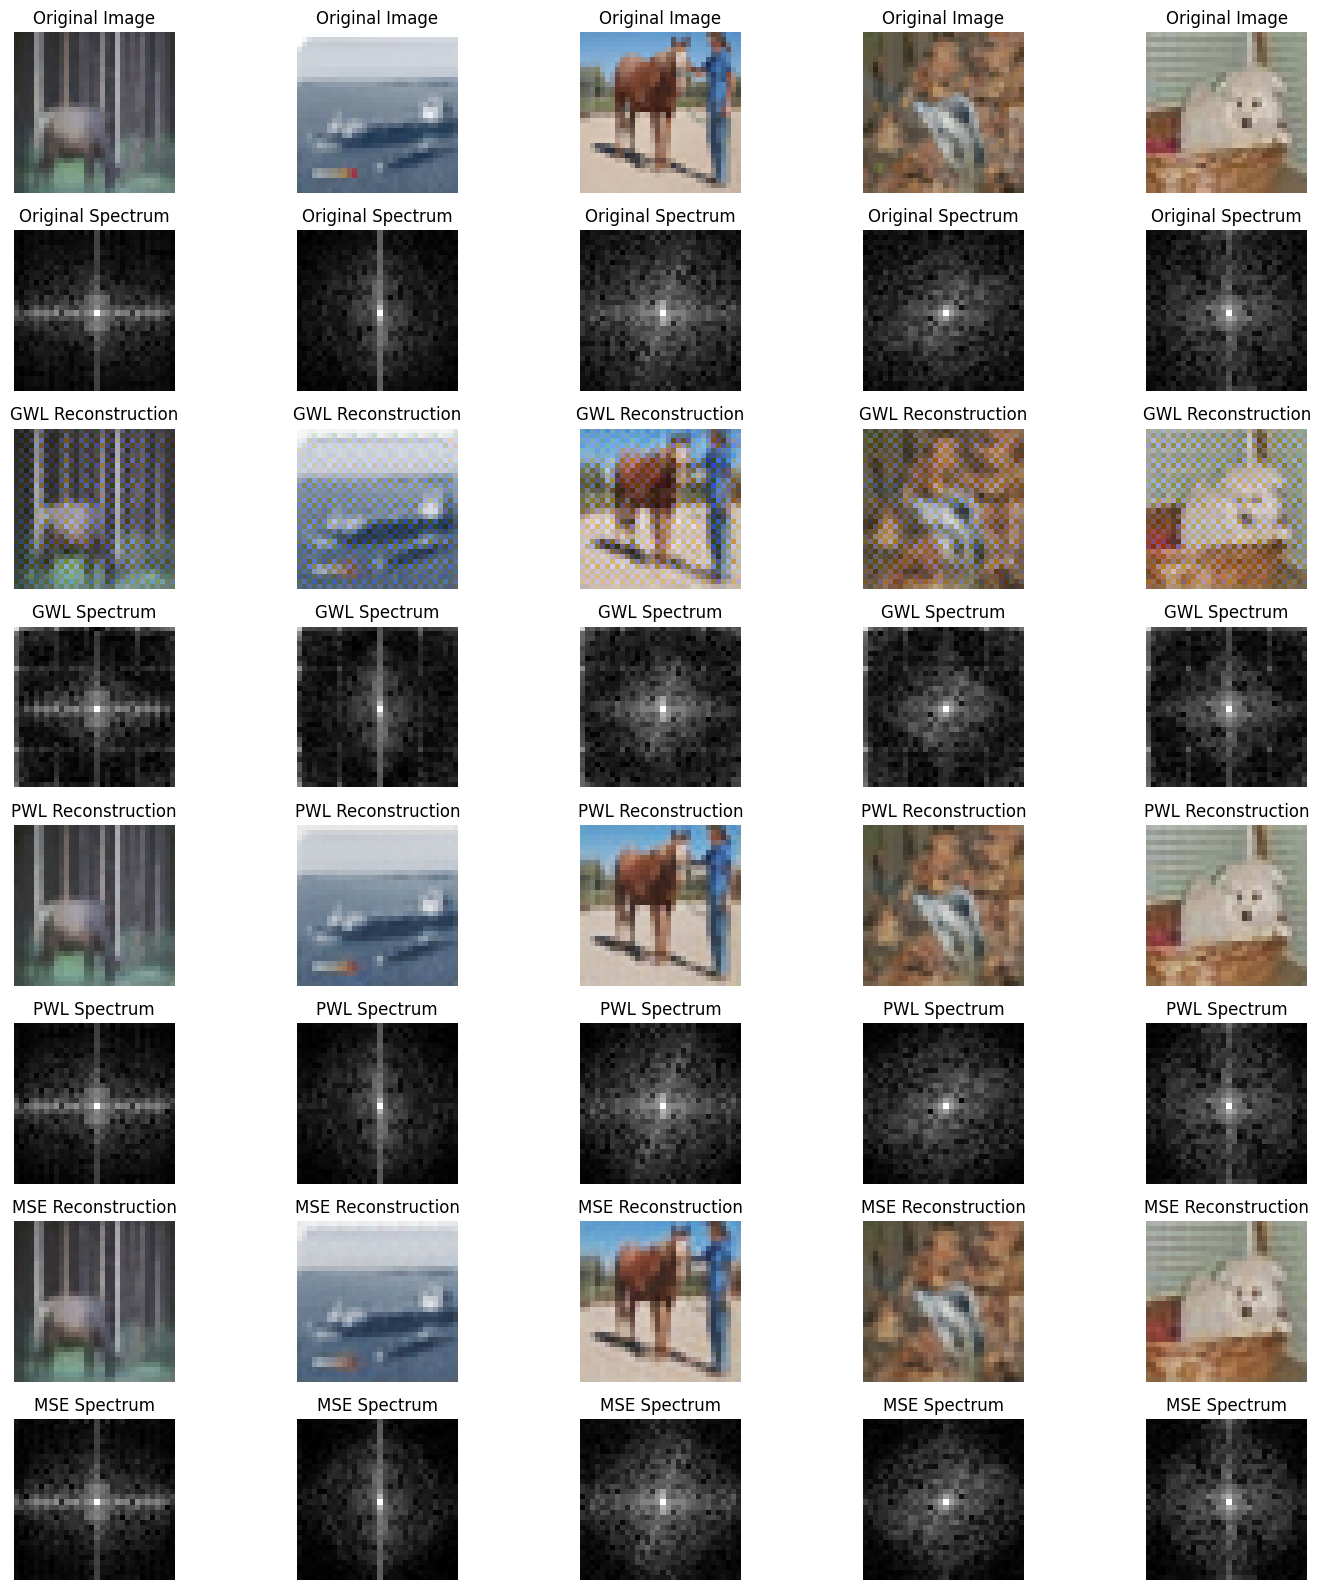

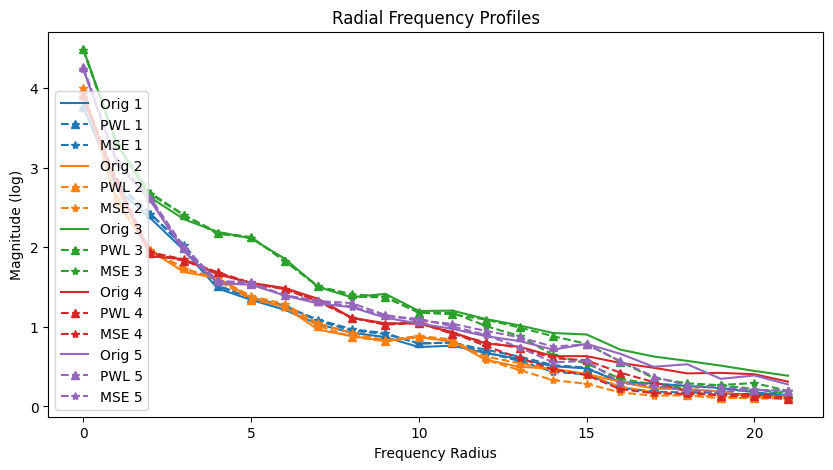

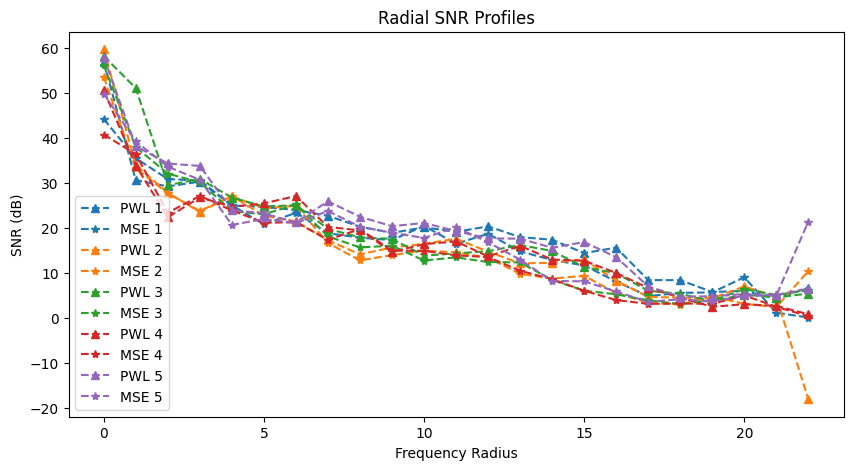

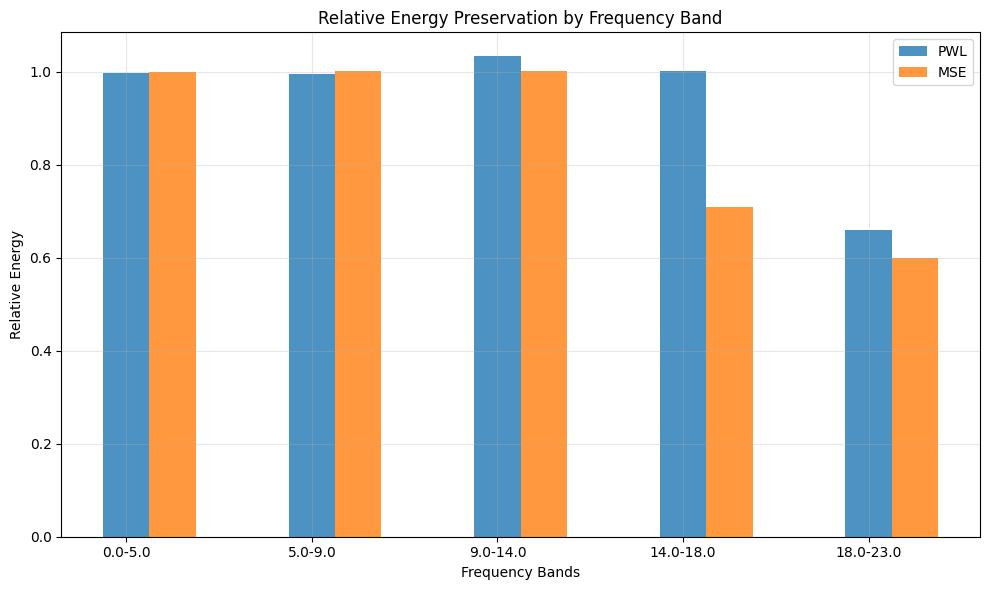

torch.Size([21, 16, 3, 32, 32]) torch.Size([20, 16, 3, 32, 32])
torch.Size([16, 3, 32, 32]) torch.Size([21, 16, 3, 32, 32]) torch.Size([20, 16, 3, 32, 32])


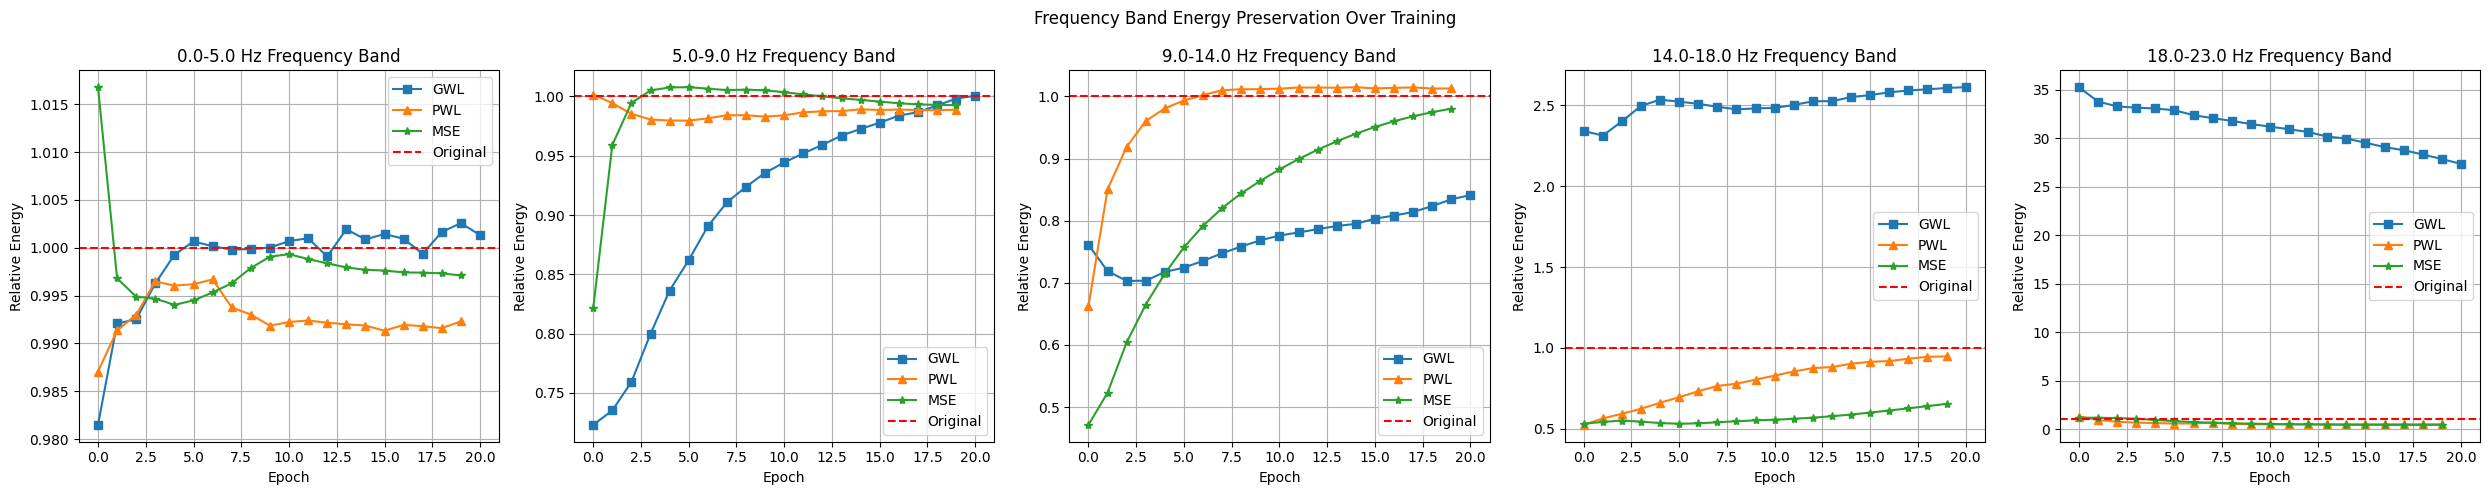

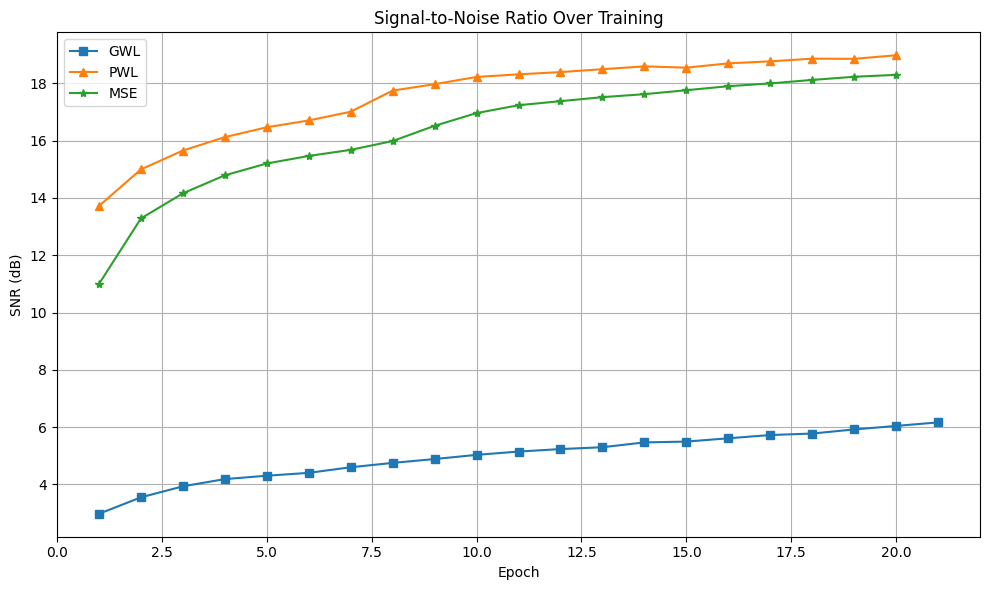

In [30]:
root_dir = "/Users/dp4018/Documents/WienerLoss/examples/wiener_exps"
epoch = min(find_checkpoint(root_dir, "WienerLoss", epoch=None)[1],
            find_checkpoint(root_dir, "PatchWienerLoss", epoch=None)[1],
            find_checkpoint(root_dir, "MSELoss", epoch=None)[1])

original, recon_gwl = load_images(root_dir, "WienerLoss", epoch=epoch)
original, recon_pwl = load_images(root_dir, "PatchWienerLoss", epoch=epoch)
original, recon_mse = load_images(root_dir, "MSELoss", epoch=epoch)

original_wiener_all, recon_wiener_all = load_images_all_epochs(root_dir, "WienerLoss")
original_pwl_all, recon_pwl_all = load_images_all_epochs(root_dir, "PatchWienerLoss")
original_mse_all, recon_mse_all = load_images_all_epochs(root_dir, "MSELoss")


# Example usage once model outputs are available
visualize_spectra_comparison(original, recon_gwl, recon_pwl, recon_mse, num_images=5)
plot_radial_profiles(original, recon_gwl, recon_pwl, recon_mse, num_images=5)
plot_radial_snr(original, recon_gwl, recon_pwl, recon_mse, num_images=5)
compare_band_energies(original, recon_gwl, recon_pwl, recon_mse, n_bands=5)
print(recon_wiener_all.shape, recon_pwl_all.shape)
plot_band_energies_over_epochs(original, recon_wiener_all, recon_pwl_all, recon_mse_all, n_bands=5)
plot_snr_over_epochs(original, recon_wiener_all, recon_pwl_all, recon_mse_all)



# TODO:
- Run same analysis on a Wiener Loss example that converges to a sensible image (e.g. MNIST) and compare progression
- Animation of recon and spectra over epochs


In [16]:
# # find the latest epoch
# epoch = min(find_checkpoint(root_dir, "WienerLoss", epoch=None)[1],
#             find_checkpoint(root_dir, "PatchWienerLoss", epoch=None)[1])

# for i in range(1, epoch + 1):
#     print("-*" * 50 + "\n" + f"\t\t\t\t\t\tEPOCH {i}" + "\n" + "-*" * 50)
#     original, recon_gwl = load_images(root_dir, "WienerLoss", epoch=i)
#     original, recon_pwl = load_images(root_dir, "PatchWienerLoss", epoch=i)
#     original, recon_mse = load_images(root_dir, "MSELoss", epoch=i)
#     visualize_spectra_comparison(original, recon_gwl, recon_pwl, recon_mse, num_images=5)

# for i in range(1, epoch):
#     print("-*" * 50 + "\n" + f"\t\t\t\t\t\tEPOCH {i}" + "\n" + "-*" * 50)
#     original, recon_gwl = load_images(root_dir, "WienerLoss", epoch=i)
#     original, recon_pwl = load_images(root_dir, "PatchWienerLoss", epoch=i)
#     original, recon_mse = load_images(root_dir, "MSELoss", epoch=i)
#     plot_radial_profiles(original, recon_gwl, recon_pwl, recon_mse, num_images=5)


# for i in range(1, epoch):
#     print("-*" * 50 + "\n" + f"\t\t\t\t\t\tEPOCH {i}" + "\n" + "-*" * 50)
#     original, recon_gwl = load_images(root_dir, "WienerLoss", epoch=i)
#     original, recon_pwl = load_images(root_dir, "PatchWienerLoss", epoch=i)
#     original, recon_mse = load_images(root_dir, "MSELoss", epoch=i)
#     plot_radial_snr(original, recon_gwl, recon_pwl, recon_mse, num_images=5)


# for i in range(1, epoch):
#     print("-*" * 50 + "\n" + f"\t\t\t\t\t\tEPOCH {i}" + "\n" + "-*" * 50)
#     original, recon_gwl = load_images(root_dir, "WienerLoss", epoch=i)
#     original, recon_pwl = load_images(root_dir, "PatchWienerLoss", epoch=i)
#     original, recon_mse = load_images(root_dir, "MSELoss", epoch=i)
#     compare_band_energies(original, recon_gwl, recon_pwl, recon_mse, n_bands=3)